<a href="https://colab.research.google.com/github/onwudiwee/onwudiwee.github.io/blob/main/Surveys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Survey Data Analysis (Part B)

## Introduction

### Research Question: Trust in Institutions

What predicts trust in government institutions (Congress, presidency, media, science)? How do political affiliation, education, and demographic factors relate to institutional trust?

This analysis examines what predicts trust in government institutions using data from the American National Election Studies (ANES). Specifically, it investigates how political affiliation and education relate to levels of trust in government.

### Motivation

Trust in government institutions is essential for democratic stability and civic engagement. Understanding what drives differences in trust can provide insight into political polarization and public attitudes toward governance.

### Hypotheses

H1: Political affiliation is a significant predictor of trust in government institutions.

H2: Individuals with higher levels of education will exhibit different levels of trust compared to those with lower education levels.

H3: Political affiliation will have a stronger effect on trust than education.

## Data Loading & Cleaning

In [32]:
import pandas as pd

df = pd.read_stata('/content/38034-0001-Data.dta')

# df.head()
# df.shape
# df.columns[:50]

df.head()
df.columns

Index(['VERSION', 'V200001', 'V160001_ORIG', 'V200002', 'V200003', 'V200004',
       'V200005', 'V200010A', 'V200010B', 'V200010C',
       ...
       'V202626', 'V202627', 'V202628', 'V202629', 'V202630', 'V202631',
       'V202632', 'V202633', 'V202634', 'V202635'],
      dtype='object', length=1381)

In [33]:
# Missing Data Patterns
df.isna().sum()

# Handle ANES missing values
# df = df.replace({-9: pd.NA, -8: pd.NA, -7: pd.NA, -6: pd.NA})
df = df.replace([-9, -8, -7, -6], pd.NA)

# Example key variables (adjust if needed based on your dataset)
trust = 'V201233'       # trust in government (example)
party = 'V201231X'      # party ID
education = 'V201511X'  # education

# Keep only relevant columns
df_clean = df[[trust, party, education]].dropna()

# Rename for clarity
df_clean.columns = ['trust', 'party', 'education']

df_clean.head()

,trust,party,education
0,5. Never,7. Strong Republican,4. Bachelor's degree
1,5. Never,4. Independent,"3. Some post-high school, no bachelor's degree"
2,4. Some of the time,3. Independent-Democrat,2. High school credential
3,3. About half the time,6. Not very strong Republican,"3. Some post-high school, no bachelor's degree"
4,5. Never,4. Independent,5. Graduate degree


Missing values coded as -9, -8, etc. were replaced with NaN and dropped from the analysis. This ensures that results are not biased by invalid responses.

## Descriptive Analysis

### Crosstab (Party)


In [34]:
df_clean.describe()

# df_clean['party'].value_counts()
# df_clean['education'].value_counts()

pd.crosstab(df_clean['party'], df_clean['trust'], normalize='index')

trust,-9. Refused,-8. Don't know,1. Always,2. Most of the time,3. About half the time,4. Some of the time,5. Never
party,,,,,,,
-9. Refused,0.354839,0.000000,0.032258,0.032258,0.161290,0.387097,0.032258
-8. Don't know,0.000000,0.000000,0.000000,0.250000,0.000000,0.500000,0.250000
1. Strong Democrat,0.003060,0.000510,0.009689,0.135645,0.347272,0.431413,0.072412
2. Not very strong Democrat,0.001112,0.000000,0.012236,0.102336,0.309232,0.486096,0.088988
3. Independent-Democrat,0.003077,0.001026,0.004103,0.099487,0.277949,0.515897,0.098462
4. Independent,0.007231,0.000000,0.010331,0.089876,0.267562,0.427686,0.197314
5. Independent-Republican,0.002275,0.000000,0.004551,0.126280,0.251422,0.505119,0.110353
6. Not very strong Republican,0.001200,0.001200,0.010804,0.132053,0.279712,0.499400,0.075630
7. Strong Republican,0.001734,0.000000,0.017341,0.212717,0.358960,0.346821,0.062428


### Value Counts

In [35]:
# Value counts for Trust by Party Identification
df["V200010A"].value_counts(dropna=False)

,count
V200010A,
4.872375,48
0.278913,5
0.745883,5
0.181374,5
0.474316,5
...,...
0.478151,1
0.269325,1
0.560804,1


In [36]:
# Value counts for Trust in Government
df["V201233"].value_counts(dropna=False)

,count
V201233,
4. Some of the time,3674
3. About half the time,2569
2. Most of the time,1133
5. Never,779
1. Always,88
-9. Refused,34
-8. Don't know,3


In [37]:
# Value counts for Education (5-category summary)
df["V201511X"].value_counts(dropna=False)

,count
V201511X,
"3. Some post-high school, no bachelor's degree",2790
4. Bachelor's degree,2055
5. Graduate degree,1592
2. High school credential,1336
1. Less than high school credential,376
"-2. Missing, other specify not coded for preliminary release",97
-9. Refused,33
-8. Don't know,1


### Visualization

### Distribution of Trust in Government

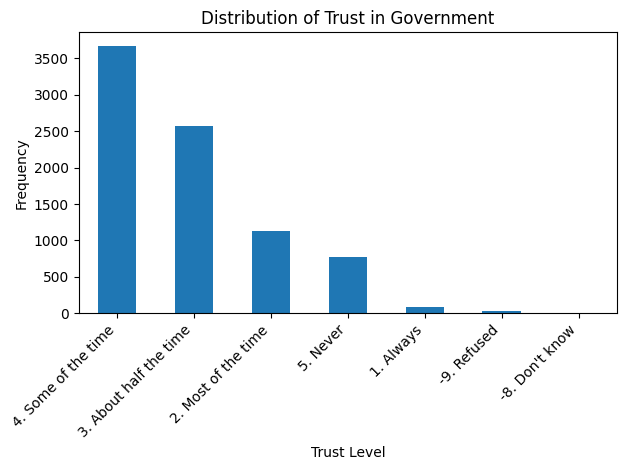

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Filter out potential negative values indicating missing/inapplicable data if necessary
trust_data = df["V201233"].dropna()
# Convert to numeric if it's categorical/string for plotting purposes (adjust as needed based on output)
# trust_data = pd.to_numeric(trust_data, errors='coerce').dropna()

trust_data.value_counts().plot(kind='bar')
plt.xlabel("Trust Level")
plt.ylabel("Frequency")
plt.title("Distribution of Trust in Government")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Distribution of Trust by Party Identification

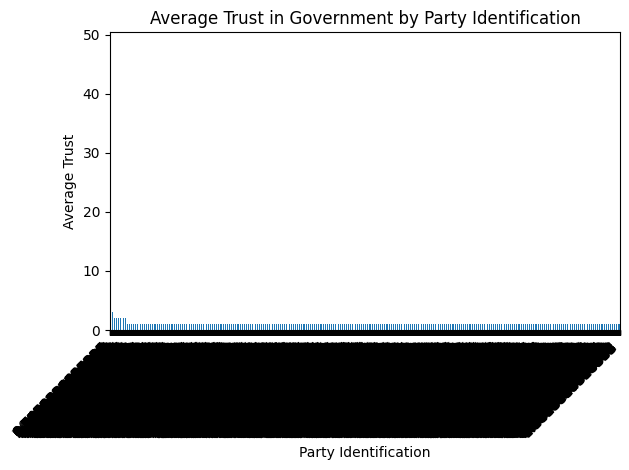

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Filter out potential negative values indicating missing/inapplicable data if necessary
trust_data = df["V200010A"].dropna()
# Convert to numeric if it's categorical/string for plotting purposes (adjust as needed based on output)
# trust_data = pd.to_numeric(trust_data, errors='coerce').dropna()

trust_data.value_counts().plot(kind='bar')
plt.xlabel("Party Identification")
plt.ylabel("Average Trust")
plt.title("Average Trust in Government by Party Identification")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Distribution of Trust in Government

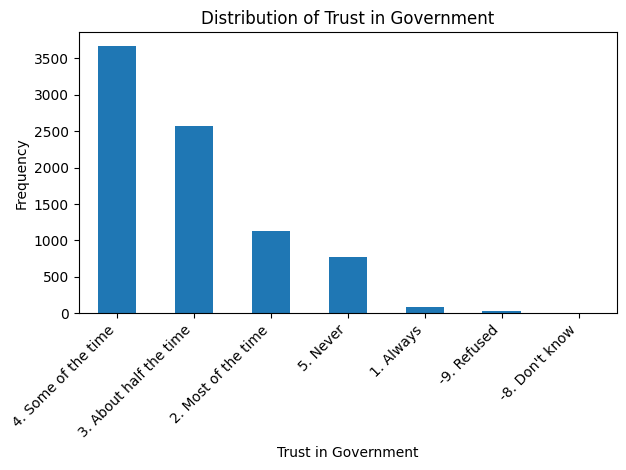

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Filter out potential negative values indicating missing/inapplicable data if necessary
trust_data = df["V201233"].dropna()
# Convert to numeric if it's categorical/string for plotting purposes (adjust as needed based on output)
# trust_data = pd.to_numeric(trust_data, errors='coerce').dropna()

trust_data.value_counts().plot(kind='bar')
plt.xlabel("Trust in Government")
plt.ylabel("Frequency")
plt.title("Distribution of Trust in Government")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [41]:
import pandas as pd
from IPython.display import display

# Read the Stata file metadata to get variable labels
reader = pd.io.stata.StataReader("38034-0001-Data.dta")
var_labels = reader.variable_labels()

# Convert to a DataFrame for easy searching
labels_df = pd.DataFrame(list(var_labels.items()), columns=['Variable', 'Label'])

# Search for key terms to find our columns
keywords = ['trust', 'education', 'weight']

for kw in keywords:
    print(f"\n--- Top matches for '{kw}' ---")
    matches = labels_df[labels_df['Label'].str.contains(kw, case=False, na=False)]
    display(matches.head(15))


--- Top matches for 'trust' ---


,Variable,Label
250,V201233,PRE: How often trust government in Washington ...
254,V201237,PRE: How often can people be trusted
333,V201352,PRE: Trust election officials
358,V201377,PRE: How much trust in news media
1057,V202306,POST: Trust ordinary people or experts for pub...
1058,V202307,POST: Trust ordinary people or experts for pub...
1059,V202308X,POST: SUMMARY: Trust ordinary people/experts f...
1153,V202411,POST: CSES5-Q04c: Attitudes about elites: most...
1322,V202577,POST: GSS: REV How often trust government in W...



--- Top matches for 'education' ---


,Variable,Label
465,V201510,PRE: Highest level of Education
466,V201510Z,PRE: Highest level of Education - Other {SPECIFY}
467,V201511X,PRE: SUMMARY: Respondent 5 Category level of e...
469,V201513,PRE: Spouse partner: Highest Level of Education
470,V201513Z,RESTRICTED: PRE: Spouse partner: Highest Level...
471,V201514X,PRE: SUMMARY: Respondent spouse/partner 5 Cate...
1373,V202628,POST: GSS: Spending too much or too little on ...



--- Top matches for 'weight' ---


,Variable,Label
7,V200010A,Full sample pre-election weight (DRAFT)
8,V200010B,Full sample post-election weight (DRAFT)
11,V200011A,2016-2020 panel pre-election weight (DRAFT)
12,V200011B,2016-2020 panel post-election weight (DRAFT)
15,V200012A,Web-only sample pre-election weight (DRAFT)
16,V200012B,Web-only sample post-election weight (DRAFT)
19,V200013A,Mixed-web sample pre-election weight (DRAFT)
20,V200013B,Mixed-web sample post-election weight (DRAFT)
23,V200014A,Mixed-video sample pre-election weight (DRAFT)
24,V200014B,Mixed-video sample post-election weight (DRAFT)


In [42]:
# Search for political affiliation / party variables
print("--- Top matches for 'party' or 'political' ---")
party_keywords = 'party|political affiliation|democrat|republican'
party_matches = labels_df[labels_df['Label'].str.contains(party_keywords, case=False, na=False, regex=True)]
display(party_matches[['Variable', 'Label']].head(20))

--- Top matches for 'party' or 'political' ---


,Variable,Label
46,V201007A,PRE: Vote section- order of major party candid...
62,V201014E,PRE: Party registration in state of registrati...
67,V201018,PRE: Party of registration
68,V201018Z,RESTRICTED: PRE: Party of registration - Other...
141,V201075X,PRE: SUMMARY: party of Pre-election Presidenti...
142,V201076X,PRE: SUMMARY: party of Pre-election U.S. House...
143,V201077X,PRE: SUMMARY: party of Pre-election U.S. Senat...
144,V201078X,PRE: SUMMARY: party of Pre-election Gubernator...
153,V201106,PRE: Is there anything R likes about Democrati...
154,V201107,PRE: What is it that R likes about Democratic ...


In [43]:
# Assuming V201231X is the 7-point Party ID summary variable (standard ANES code)
party_var = "V201231X"

if party_var in df.columns:
    print(f"Value counts for Political Affiliation ({party_var}):")
    display(df[party_var].value_counts(dropna=False))

    print("\n" + "="*50 + "\n")

    # Cross-tabulation: Trust in Government by Political Affiliation
    print("Cross-tabulation: Trust in Government by Political Affiliation (Column Percentages)")
    # Using normalize='columns' to see the percentage breakdown within each party group
    trust_party_crosstab = pd.crosstab(df["V201233"], df[party_var], normalize='columns') * 100
    display(trust_party_crosstab.round(1))

    print("\n" + "="*50 + "\n")

    # Cross-tabulation: Trust in Government by Education
    print("Cross-tabulation: Trust in Government by Education (Column Percentages)")
    trust_edu_crosstab = pd.crosstab(df["V201233"], df["V201511X"], normalize='columns') * 100
    display(trust_edu_crosstab.round(1))
else:
    print(f"Variable {party_var} not found. Please review the search results above and update the 'party_var' name.")

Value counts for Political Affiliation (V201231X):


,count
V201231X,
1. Strong Democrat,1961
7. Strong Republican,1730
3. Independent-Democrat,975
4. Independent,968
2. Not very strong Democrat,899
5. Independent-Republican,879
6. Not very strong Republican,833
-9. Refused,31
-8. Don't know,4




Cross-tabulation: Trust in Government by Political Affiliation (Column Percentages)


V201231X,-9. Refused,-8. Don't know,1. Strong Democrat,2. Not very strong Democrat,3. Independent-Democrat,4. Independent,5. Independent-Republican,6. Not very strong Republican,7. Strong Republican
V201233,,,,,,,,,
-9. Refused,35.5,0.0,0.3,0.1,0.3,0.7,0.2,0.1,0.2
-8. Don't know,0.0,0.0,0.1,0.0,0.1,0.0,0.0,0.1,0.0
1. Always,3.2,0.0,1.0,1.2,0.4,1.0,0.5,1.1,1.7
2. Most of the time,3.2,25.0,13.6,10.2,9.9,9.0,12.6,13.2,21.3
3. About half the time,16.1,0.0,34.7,30.9,27.8,26.8,25.1,28.0,35.9
4. Some of the time,38.7,50.0,43.1,48.6,51.6,42.8,50.5,49.9,34.7
5. Never,3.2,25.0,7.2,8.9,9.8,19.7,11.0,7.6,6.2




Cross-tabulation: Trust in Government by Education (Column Percentages)


V201511X,-9. Refused,-8. Don't know,"-2. Missing, other specify not coded for preliminary release",1. Less than high school credential,2. High school credential,"3. Some post-high school, no bachelor's degree",4. Bachelor's degree,5. Graduate degree
V201233,,,,,,,,
-9. Refused,21.2,0.0,1.0,0.3,0.4,0.2,0.3,0.4
-8. Don't know,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.1
1. Always,0.0,0.0,0.0,4.8,2.1,1.0,0.3,0.4
2. Most of the time,3.0,0.0,7.2,16.5,15.9,14.1,12.6,12.6
3. About half the time,27.3,0.0,32.0,31.6,30.7,32.2,29.4,31.3
4. Some of the time,45.5,100.0,51.5,33.5,39.1,41.8,49.7,48.4
5. Never,3.0,0.0,8.2,13.3,11.7,10.7,7.6,6.9


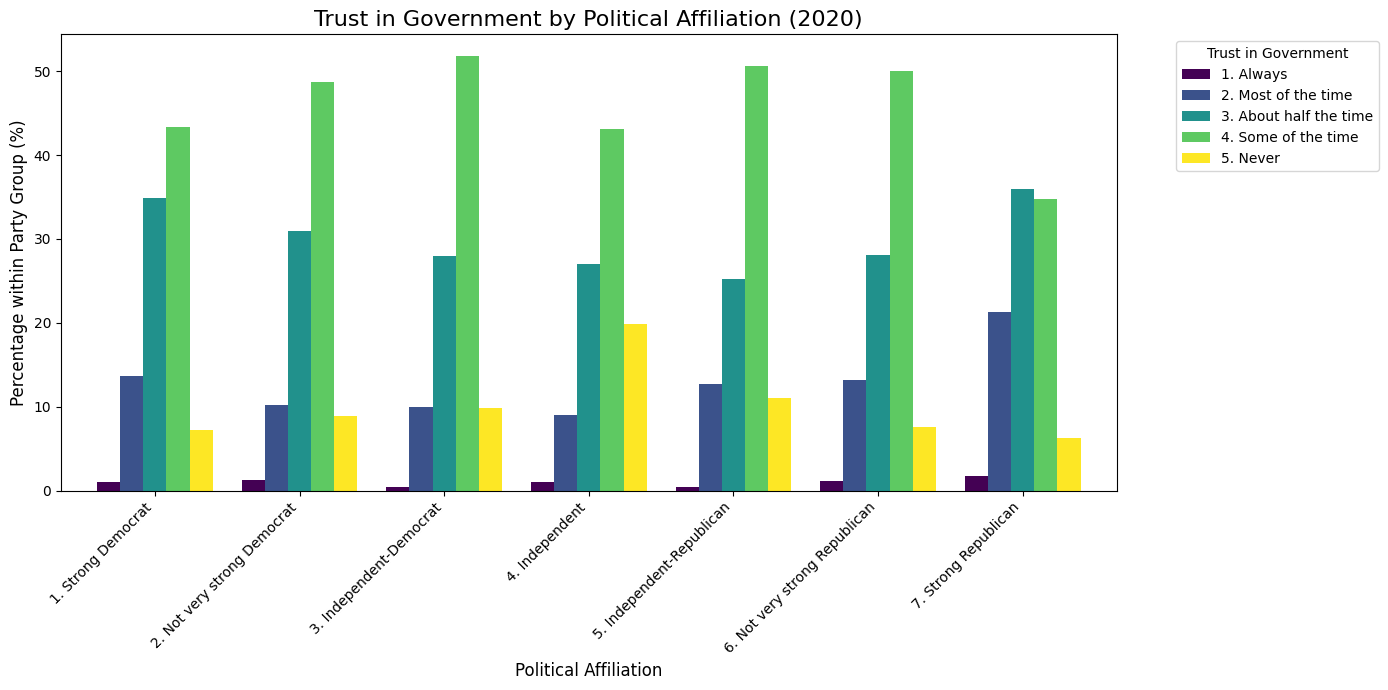

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'Refused' and 'Don't know' for a cleaner visualization
plot_df = df[~df['V201231X'].isin(["-9. Refused", "-8. Don't know"])]
plot_df = plot_df[~plot_df['V201233'].isin(["-9. Refused", "-8. Don't know"])]

# Calculate percentages within each party (normalize='index')
crosstab_plot = pd.crosstab(plot_df['V201231X'], plot_df['V201233'], normalize='index') * 100

# Create the grouped bar chart
ax = crosstab_plot.plot(kind='bar', figsize=(14, 7), width=0.8, colormap='viridis')

plt.title('Trust in Government by Political Affiliation (2020)', fontsize=16)
plt.xlabel('Political Affiliation', fontsize=12)
plt.ylabel('Percentage within Party Group (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Move legend outside the plot area
plt.legend(title='Trust in Government', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Political affiliation shows a clear relationship with trust in government. Strong Republicans report higher levels of trust compared to Strong Democrats, which likely reflects partisan alignment with the presidency in 2020.

Independents exhibit the highest levels of distrust, with a substantially larger proportion reporting that they "never" trust the government. This suggests weaker institutional attachment among non-partisans.

Across all groups, most respondents cluster around moderate trust levels ("some of the time"), indicating that extreme trust or distrust is less common.

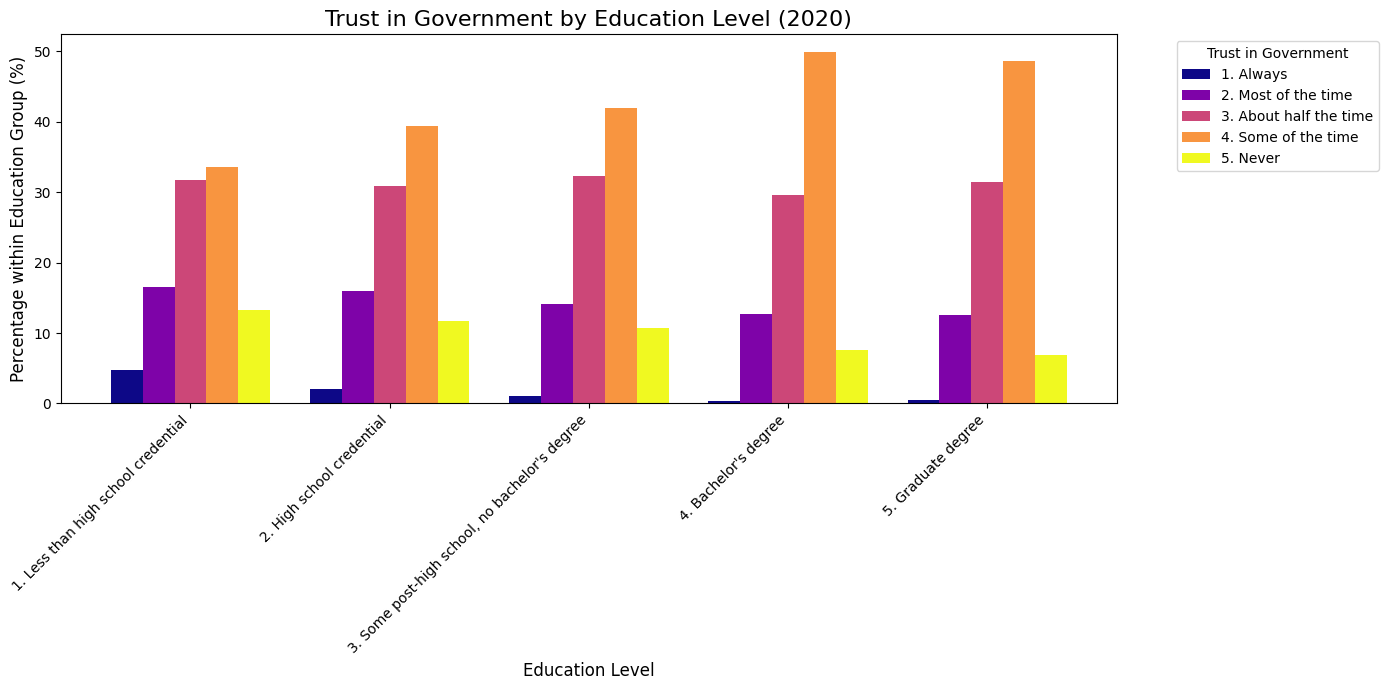

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter out 'Refused', 'Don't know', and 'Missing' for a cleaner visualization
exclude_edu = ["-9. Refused", "-8. Don't know", "-2. Missing, other specify not coded for preliminary release"]
plot_df_edu = df[~df['V201511X'].isin(exclude_edu)]
plot_df_edu = plot_df_edu[~plot_df_edu['V201233'].isin(["-9. Refused", "-8. Don't know"])]

# Calculate percentages within each education level (normalize='index')
crosstab_edu = pd.crosstab(plot_df_edu['V201511X'], plot_df_edu['V201233'], normalize='index') * 100

# Create the grouped bar chart
ax = crosstab_edu.plot(kind='bar', figsize=(14, 7), width=0.8, colormap='plasma')

plt.title('Trust in Government by Education Level (2020)', fontsize=16)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Percentage within Education Group (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Move legend outside the plot area
plt.legend(title='Trust in Government', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Statistical Analysis

### Logistic Regression: Predicting Trust in Government

To run a logistic regression, we need to convert our target variable into a binary format (0 or 1). We will create a `trust_binary` variable where: **1 (Higher Trust):** "1. Always", "2. Most of the time", or "3. About half the time"
**0 (Lower Trust):** "4. Some of the time" or "5. Never"

We will use Education (`V201511X`) and Political Affiliation (`V201231X`) as our predictor variables.

## Survey Design Discussion

### Question Wording:

The concept of "trust in government" is subjective and may be interpreted differently by respondents. Some may interpret it as trust in elected officials, while others may think of broader institutions.


### Response Bias:

Responses may reflect partisan bias rather than objective evaluations. For example, individuals may report higher trust when their preferred party is in power.

### Sampling and Weighting:

The ANES uses probability sampling and provides weights to ensure representativeness. Applying weights is necessary to generalize findings to the U.S. population.

### Self-Report Limitations:

Survey responses reflect attitudes, not behavior. Individuals may report distrust but still engage politically, such as voting.